In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
#importing dataset
df = pd.read_csv('/kaggle/input/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
df.head(3)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


In [3]:
#getting info about all the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
#getting statiscal data about each numerical columns

df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
#checking if dataset contains any null values
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
#checking number of unique values in a column
df['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

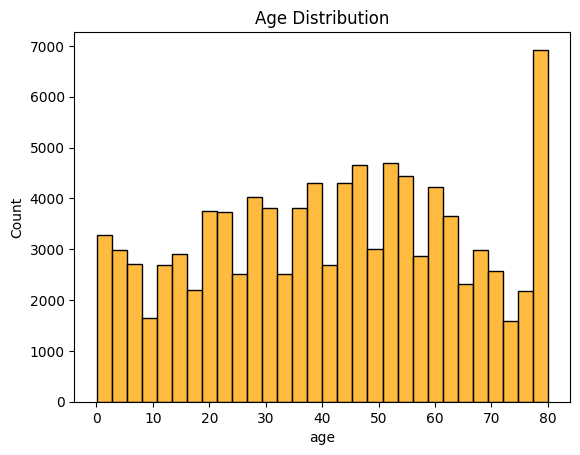

In [7]:
#Age Distribution
sns.histplot(df['age'], bins=30, color='orange')
plt.title("Age Distribution")
plt.show()

Text(0.5, 1.0, 'Hypertension Prevalence')

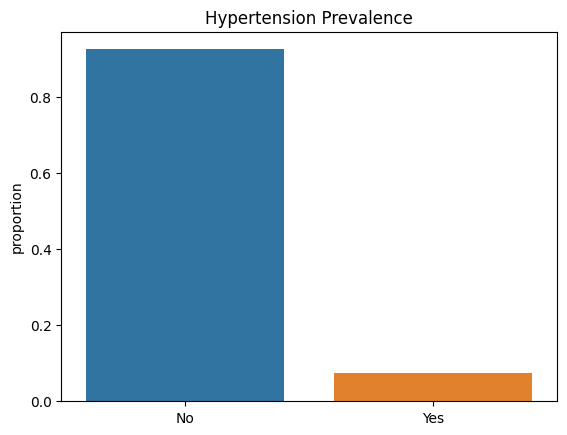

In [8]:
#Hypertension & Heart Disease Prevalence
sns.barplot(x=['No', 'Yes'], y=df['hypertension'].value_counts(normalize=True))
plt.title("Hypertension Prevalence")

Text(0.5, 1.0, 'BMI Distribution')

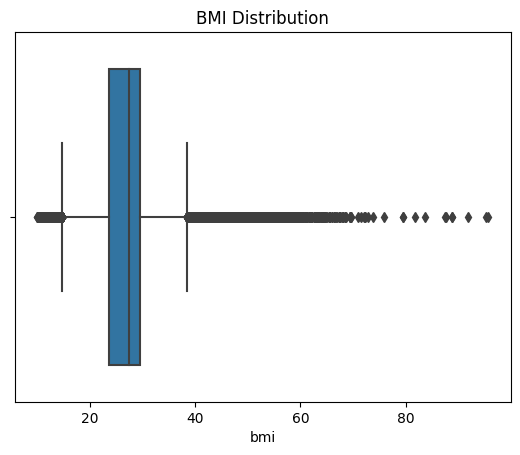

In [9]:
#BMI Distribution ans Outliers
sns.boxplot(x=df['bmi'])
plt.title("BMI Distribution")

In [10]:
df['bmi'].value_counts()

bmi
27.32    25495
23.00      103
27.12      101
27.80      100
24.96      100
         ...  
58.23        1
48.18        1
55.57        1
57.07        1
60.52        1
Name: count, Length: 4247, dtype: int64

In [11]:
#Performing outlier treatment on BMI
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Finding outliers
outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f'Number of outliers in BMI column: {len(outliers)}')

Number of outliers in BMI column: 7086


In [12]:
#New df with no outliers in BMI column
df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]

Text(0.5, 1.0, 'BMI Distribution')

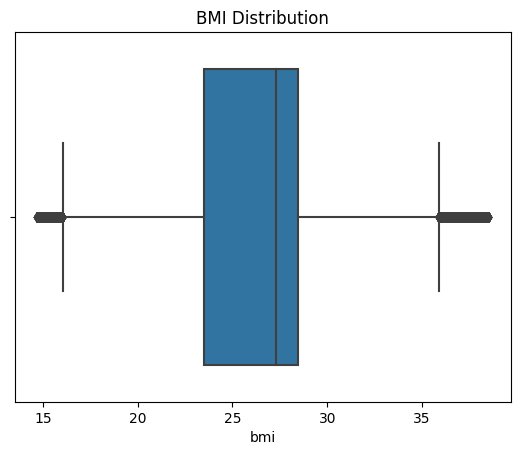

In [13]:
sns.boxplot(x=df['bmi'])
plt.title("BMI Distribution")

In [14]:
df.smoking_history.value_counts()

smoking_history
No Info        33726
never          32393
current         8624
former          8506
not current     5988
ever            3677
Name: count, dtype: int64

In [15]:
#Based on smoking , mapping to a value
smoking_history_map = {
    'never': 0,          # Non-Smoker
    'not current': 0,    # Non-Smoker
    'former': 1,         # Former Smoker
    'current': 2,        # Smoker
    'ever': 2,           # Smoker (considered similar to 'current')
    'No Info': -1        # Unknown
}
df['smoking_history'] = df['smoking_history'].map(smoking_history_map)

In [16]:
df.head(3)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,0,25.19,6.6,140,0
1,Female,54.0,0,0,-1,27.32,6.6,80,0
2,Male,28.0,0,0,0,27.32,5.7,158,0


In [17]:
df['gender'].value_counts()

gender
Female    53796
Male      39101
Other        17
Name: count, dtype: int64

In [18]:
# Remove rows where gender is "Other"
df = df[df['gender'] != 'Other']

# Mapping dictionary for gender (Female: 0, Male: 1)
gender_map = {
    'Female': 0,
    'Male': 1
}

# Apply the mapping to the 'gender' column
df['gender'] = df['gender'].map(gender_map)

In [19]:
#scaling data to bring all values to a Range [0,1]

scaler = MinMaxScaler()
# Apply scaling to the columns (exclude categorical ones)
df[['age','smoking_history','bmi','HbA1c_level', 'blood_glucose_level']] = scaler.fit_transform(df[['age','smoking_history','bmi','HbA1c_level', 'blood_glucose_level']])

In [20]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
# Initialize the Logistic Regression Model
model_logistic = LogisticRegression(class_weight='balanced', random_state=42)

# Train the model
model_logistic.fit(X_train, y_train)

# Make predictions
y_pred = model_logistic.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.883745963401507
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.88      0.93     25803
           1       0.38      0.88      0.53      2067

    accuracy                           0.88     27870
   macro avg       0.68      0.88      0.73     27870
weighted avg       0.94      0.88      0.90     27870

Confusion Matrix:
 [[22801  3002]
 [  238  1829]]


In [22]:
# Initialize the Random Forest Classifier model
model_rfc = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model
model_rfc.fit(X_train, y_train)

# Make predictions
y_pred = model_rfc.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9728022963760316
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     25803
           1       0.94      0.68      0.79      2067

    accuracy                           0.97     27870
   macro avg       0.96      0.84      0.89     27870
weighted avg       0.97      0.97      0.97     27870

Confusion Matrix:
 [[25711    92]
 [  666  1401]]


<h3>Clearly Random Forest Classifier gives more accuracy than Logistic Regression </h3>

In [ ]:
# Export the trained model and scaler
import joblib

# Save the model
joblib.dump(model_rfc, 'diabetes_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')